# 第 2 步：基础模型训练

本 notebook 完成以下任务：
1. 加载预处理好的数据
2. 训练 LSTM 基线模型
3. 训练 Transformer 基线模型
4. 评估模型性能

**使用的数据集**：ETTh1（小时级，少变量）、ETTm1（15分钟级，高频）、ECL（小时级，多变量321个）

## 1. 环境检查与导入

In [15]:
import sys
import os

# 添加项目根目录到路径
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from models import LSTMModel, TransformerModel, TimeSeriesDataset, Trainer
from torch.utils.data import DataLoader

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'设备: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.10.0+cu126
CUDA available: True
设备: cuda


## 2. 数据集配置

## 评估指标说明

本项目使用以下 4 个指标评估模型预测质量（均基于**归一化后**的数据计算）：

| 指标 | 公式 | 含义 | 取值范围 |
|------|------|------|----------|
| **MSE**（均方误差） | $\frac{1}{n}\sum(y-\hat{y})^2$ | 对**大误差**敏感，是训练时的损失函数 | ≥ 0，越小越好 |
| **MAE**（平均绝对误差） | $\frac{1}{n}\sum\|y-\hat{y}\|$ | 直观反映**平均偏差大小**，对异常值不敏感 | ≥ 0，越小越好 |
| **MAPE**（平均绝对百分比误差） | $\frac{100\%}{n}\sum\|\frac{y-\hat{y}}{y}\|$ | 以**百分比**表示误差，便于跨数据集比较 | ≥ 0%，越小越好 |
| **R²**（决定系数） | $1 - \frac{\sum(y-\hat{y})^2}{\sum(y-\bar{y})^2}$ | 衡量模型**解释数据方差**的能力 | ≤ 1，越接近 1 越好 |

> **简单理解**：MSE/MAE 越小 = 预测越准；R² 越接近 1 = 模型拟合越好。

In [16]:
# 数据集配置
dataset=["ETTh1","ETTM1","ECL"]
HORIZON_LIST=[24,48,96,168,336]

DATASET = dataset[0]  # 可选: ETTh1, ETTm1, ECL
HORIZON = HORIZON_LIST[0]     # 预测步长: 24, 48, 96, 168, 336
BATCH_SIZE = 32
DATA_DIR = os.path.join(ROOT, 'data', 'processed')

print(f'数据集: {DATASET}')
print(f'预测步长: {HORIZON}')
print(f'批次大小: {BATCH_SIZE}')

数据集: ETTh1
预测步长: 24
批次大小: 32


## 3. 加载数据

In [17]:
# 创建数据加载器
train_dataset = TimeSeriesDataset(DATA_DIR, DATASET, HORIZON, 'train')
val_dataset = TimeSeriesDataset(DATA_DIR, DATASET, HORIZON, 'val')
test_dataset = TimeSeriesDataset(DATA_DIR, DATASET, HORIZON, 'test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

input_size = train_dataset.input_size
target_idx = train_dataset.target_idx

print(f'输入特征数: {input_size}')
print(f'目标列索引: {target_idx}')
print(f'训练样本: {len(train_dataset)}')
print(f'验证样本: {len(val_dataset)}')
print(f'测试样本: {len(test_dataset)}')

加载 ETTh1 train 数据: X=torch.Size([8521, 96, 7]), Y=torch.Size([8521, 24, 7])
加载 ETTh1 val 数据: X=torch.Size([2761, 96, 7]), Y=torch.Size([2761, 24, 7])
加载 ETTh1 test 数据: X=torch.Size([5781, 96, 7]), Y=torch.Size([5781, 24, 7])
输入特征数: 7
目标列索引: 6
训练样本: 8521
验证样本: 2761
测试样本: 5781


## 4. 训练 LSTM 模型

In [18]:
# 创建 LSTM 模型
lstm_model = LSTMModel(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.1,
    horizon=HORIZON
)

print(f'LSTM 模型参数量: {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTM 模型参数量: 240,424


In [19]:
# 训练 LSTM（使用 GPU）
lstm_trainer = Trainer(lstm_model, device='cuda', lr=3e-4)
lstm_history = lstm_trainer.train(
    train_loader, val_loader,
    epochs=100,
    patience=20,
    save_dir=os.path.join(ROOT, 'checkpoints'),
    model_name=f'LSTM_{DATASET}_h{HORIZON}',
    log_dir=os.path.join(ROOT, 'runs/LSTM')
)

TensorBoard 日志: c:\Users\LOKER\Desktop\Research-Training\runs/LSTM\LSTM_ETTh1_h24
开始训练: LSTM_ETTh1_h24
设备: cuda
训练样本: 8521
验证样本: 2761
批次大小: 32
Epoch   1/100 | Train Loss: 0.603991 R²: 0.3885 | Val Loss: 1.088779 R²: 0.1816 ✓ | Time: 1.1s
Epoch   2/100 | Train Loss: 0.381380 R²: 0.6125 | Val Loss: 0.948760 R²: 0.3182 ✓ | Time: 1.0s
Epoch   3/100 | Train Loss: 0.330906 R²: 0.6637 | Val Loss: 0.928657 R²: 0.3304 ✓ | Time: 0.9s
Epoch   4/100 | Train Loss: 0.304842 R²: 0.6903 | Val Loss: 0.950101 R²: 0.3263 | Time: 1.0s
Epoch   5/100 | Train Loss: 0.284240 R²: 0.7112 | Val Loss: 0.934540 R²: 0.3428 | Time: 1.0s
Epoch   6/100 | Train Loss: 0.268458 R²: 0.7277 | Val Loss: 0.950403 R²: 0.3362 | Time: 1.0s
Epoch   7/100 | Train Loss: 0.256386 R²: 0.7396 | Val Loss: 0.973806 R²: 0.3062 | Time: 1.0s
Epoch   8/100 | Train Loss: 0.243971 R²: 0.7528 | Val Loss: 1.013303 R²: 0.2783 | Time: 1.0s
Epoch   9/100 | Train Loss: 0.232368 R²: 0.7640 | Val Loss: 1.002551 R²: 0.2957 | Time: 1.0s
Epoch  10/100 

In [20]:
# 检查 history 包含的键
print("lstm_history 的键:", list(lstm_history.keys()))

lstm_history 的键: ['train_losses', 'val_losses', 'train_r2', 'val_r2', 'best_val_loss', 'best_val_r2']


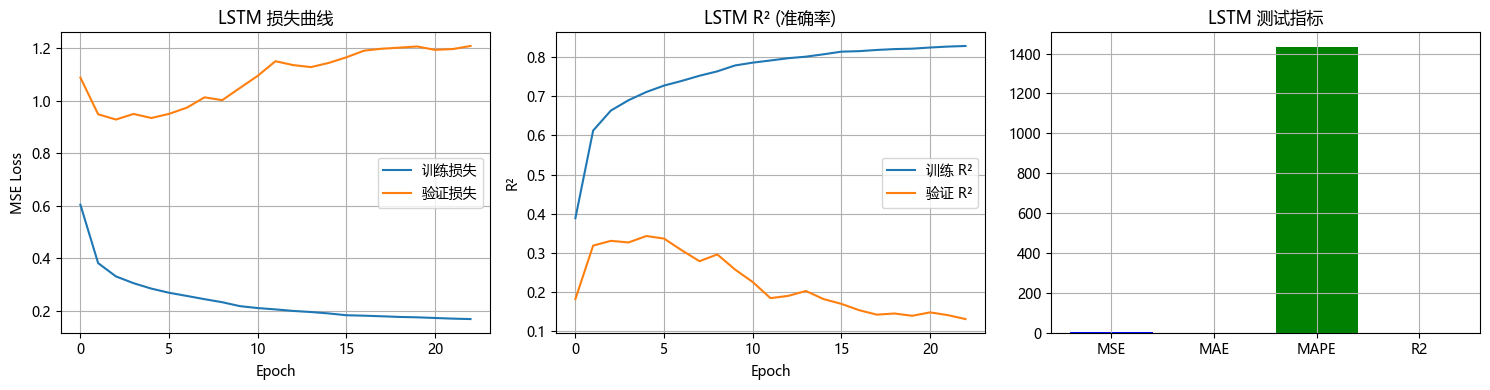

LSTM 测试结果:
  MSE: 1.245660
  MAE: 0.830797
  MAPE: 1435.05%
  R² (准确率): 0.0254
  MSE (目标列): 0.276781
  R² (目标列): -0.7869


In [21]:
# 绘制 LSTM 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 损失曲线
axes[0].plot(lstm_history['train_losses'], label='训练损失')
axes[0].plot(lstm_history['val_losses'], label='验证损失')
axes[0].set_title('LSTM 损失曲线')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# R² 曲线（准确率）
axes[1].plot(lstm_history['train_r2'], label='训练 R²')
axes[1].plot(lstm_history['val_r2'], label='验证 R²')
axes[1].set_title('LSTM R² (准确率)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True)

# 测试 LSTM
lstm_preds, lstm_targets = lstm_trainer.predict(test_loader)
lstm_metrics = lstm_trainer.compute_metrics(lstm_preds, lstm_targets, target_idx)

# 测试指标
metrics_names = ['MSE', 'MAE', 'MAPE', 'R2']
values = [lstm_metrics['MSE'], lstm_metrics['MAE'], lstm_metrics['MAPE'], lstm_metrics['R2']]
axes[2].bar(metrics_names, values, color=['blue', 'orange', 'green', 'red'])
axes[2].set_title('LSTM 测试指标')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f'LSTM 测试结果:')
print(f'  MSE: {lstm_metrics["MSE"]:.6f}')
print(f'  MAE: {lstm_metrics["MAE"]:.6f}')
print(f'  MAPE: {lstm_metrics["MAPE"]:.2f}%')
print(f'  R² (准确率): {lstm_metrics["R2"]:.4f}')
print(f'  MSE (目标列): {lstm_metrics["MSE_target"]:.6f}')
print(f'  R² (目标列): {lstm_metrics["R2_target"]:.4f}')

## 5. 训练 Transformer 模型

In [22]:
# 创建 Transformer 模型
transformer_model = TransformerModel(
    input_size=input_size,
    d_model=128,
    nhead=8,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    horizon=HORIZON
)

print(f'Transformer 模型参数量: {sum(p.numel() for p in transformer_model.parameters()):,}')

Transformer 模型参数量: 171,688


In [23]:
# 训练 Transformer（使用 GPU）
transformer_trainer = Trainer(transformer_model, device='cuda', lr=5e-5)
transformer_history = transformer_trainer.train(
    train_loader, val_loader,
    epochs=100,
    patience=15,
    save_dir=os.path.join(ROOT, 'checkpoints'),
    model_name=f'Transformer_{DATASET}_h{HORIZON}',
    log_dir=os.path.join(ROOT, 'runs/Transformer')
)

TensorBoard 日志: c:\Users\LOKER\Desktop\Research-Training\runs/Transformer\Transformer_ETTh1_h24
开始训练: Transformer_ETTh1_h24
设备: cuda
训练样本: 8521
验证样本: 2761
批次大小: 32
Epoch   1/100 | Train Loss: 0.911465 R²: 0.0791 | Val Loss: 1.288041 R²: -0.0366 ✓ | Time: 1.8s
Epoch   2/100 | Train Loss: 0.642033 R²: 0.3489 | Val Loss: 1.104751 R²: 0.1276 ✓ | Time: 1.8s
Epoch   3/100 | Train Loss: 0.536744 R²: 0.4556 | Val Loss: 1.006190 R²: 0.2125 ✓ | Time: 1.9s
Epoch   4/100 | Train Loss: 0.477680 R²: 0.5153 | Val Loss: 0.917531 R²: 0.2908 ✓ | Time: 1.9s
Epoch   5/100 | Train Loss: 0.431004 R²: 0.5635 | Val Loss: 0.837160 R²: 0.3595 ✓ | Time: 1.8s
Epoch   6/100 | Train Loss: 0.399632 R²: 0.5941 | Val Loss: 0.802399 R²: 0.3906 ✓ | Time: 1.8s
Epoch   7/100 | Train Loss: 0.379018 R²: 0.6156 | Val Loss: 0.772537 R²: 0.4136 ✓ | Time: 1.7s
Epoch   8/100 | Train Loss: 0.364696 R²: 0.6301 | Val Loss: 0.754539 R²: 0.4202 ✓ | Time: 1.7s
Epoch   9/100 | Train Loss: 0.354079 R²: 0.6405 | Val Loss: 0.739856 R²: 0.

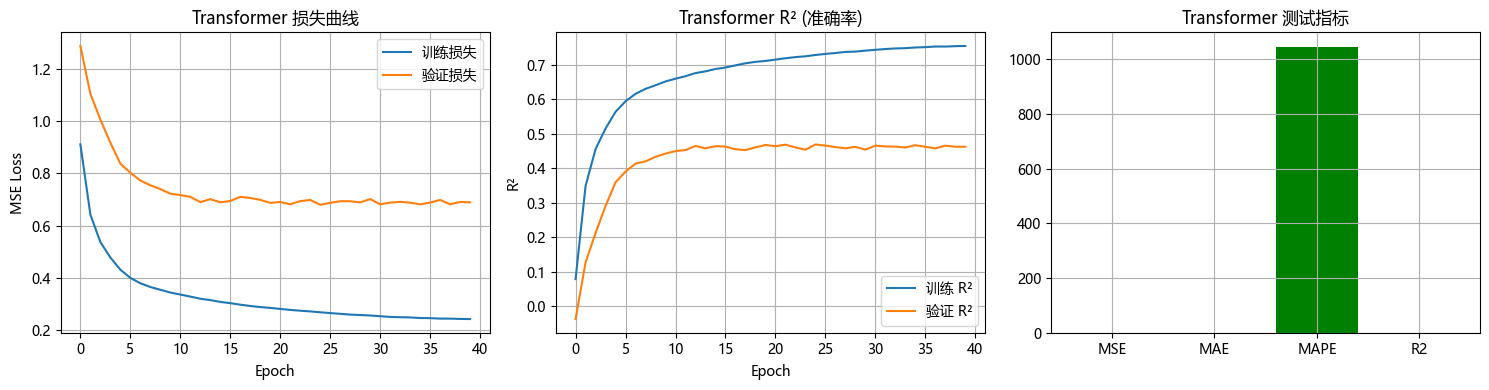

Transformer 测试结果:
  MSE: 0.776820
  MAE: 0.655572
  MAPE: 1046.07%
  R² (准确率): 0.3922
  MSE (目标列): 0.204705
  R² (目标列): -0.3216


In [24]:
# 绘制 Transformer 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 损失曲线
axes[0].plot(transformer_history['train_losses'], label='训练损失')
axes[0].plot(transformer_history['val_losses'], label='验证损失')
axes[0].set_title('Transformer 损失曲线')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# R² 曲线（准确率）
axes[1].plot(transformer_history['train_r2'], label='训练 R²')
axes[1].plot(transformer_history['val_r2'], label='验证 R²')
axes[1].set_title('Transformer R² (准确率)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True)

# 测试 Transformer
transformer_preds, transformer_targets = transformer_trainer.predict(test_loader)
transformer_metrics = transformer_trainer.compute_metrics(transformer_preds, transformer_targets, target_idx)

# 测试指标
metrics_names = ['MSE', 'MAE', 'MAPE', 'R2']
values = [transformer_metrics['MSE'], transformer_metrics['MAE'], transformer_metrics['MAPE'], transformer_metrics['R2']]
axes[2].bar(metrics_names, values, color=['blue', 'orange', 'green', 'red'])
axes[2].set_title('Transformer 测试指标')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f'Transformer 测试结果:')
print(f'  MSE: {transformer_metrics["MSE"]:.6f}')
print(f'  MAE: {transformer_metrics["MAE"]:.6f}')
print(f'  MAPE: {transformer_metrics["MAPE"]:.2f}%')
print(f'  R² (准确率): {transformer_metrics["R2"]:.4f}')
print(f'  MSE (目标列): {transformer_metrics["MSE_target"]:.6f}')
print(f'  R² (目标列): {transformer_metrics["R2_target"]:.4f}')

## 6. 模型对比

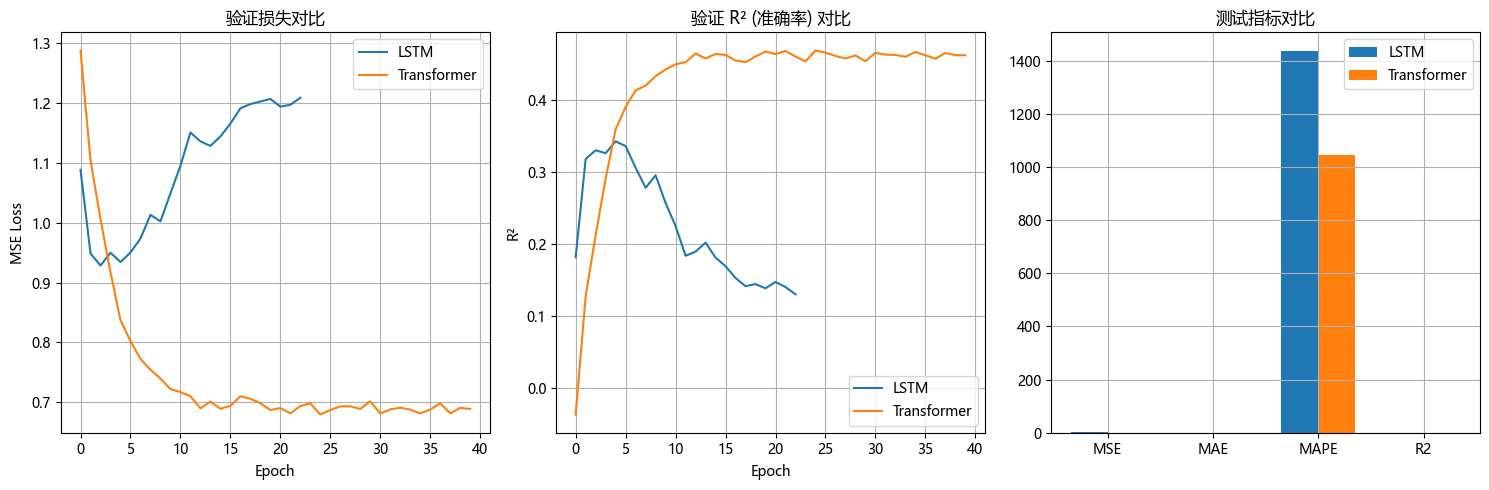


模型对比:
------------------------------------------------------------
指标         LSTM            Transformer    
------------------------------------------------------------
MSE        1.245660        0.776820       
MAE        0.830797        0.655572       
MAPE       1435.045898     1046.074707    
R2         0.025380        0.392206       
------------------------------------------------------------


In [25]:
# 模型对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 训练曲线对比
axes[0].plot(lstm_history['val_losses'], label='LSTM')
axes[0].plot(transformer_history['val_losses'], label='Transformer')
axes[0].set_title('验证损失对比')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# R² 对比（准确率）
axes[1].plot(lstm_history['val_r2'], label='LSTM')
axes[1].plot(transformer_history['val_r2'], label='Transformer')
axes[1].set_title('验证 R² (准确率) 对比')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True)

# 测试指标对比
metrics_names = ['MSE', 'MAE', 'MAPE', 'R2']
x = np.arange(len(metrics_names))
width = 0.35

axes[2].bar(x - width/2, [lstm_metrics[m] for m in metrics_names], width, label='LSTM')
axes[2].bar(x + width/2, [transformer_metrics[m] for m in metrics_names], width, label='Transformer')
axes[2].set_title('测试指标对比')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics_names)
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# 打印对比表
print('\n模型对比:')
print('-' * 60)
print(f'{"指标":<10} {"LSTM":<15} {"Transformer":<15}')
print('-' * 60)
for m in metrics_names:
    print(f'{m:<10} {lstm_metrics[m]:<15.6f} {transformer_metrics[m]:<15.6f}')
print('-' * 60)

## 7. 预测可视化

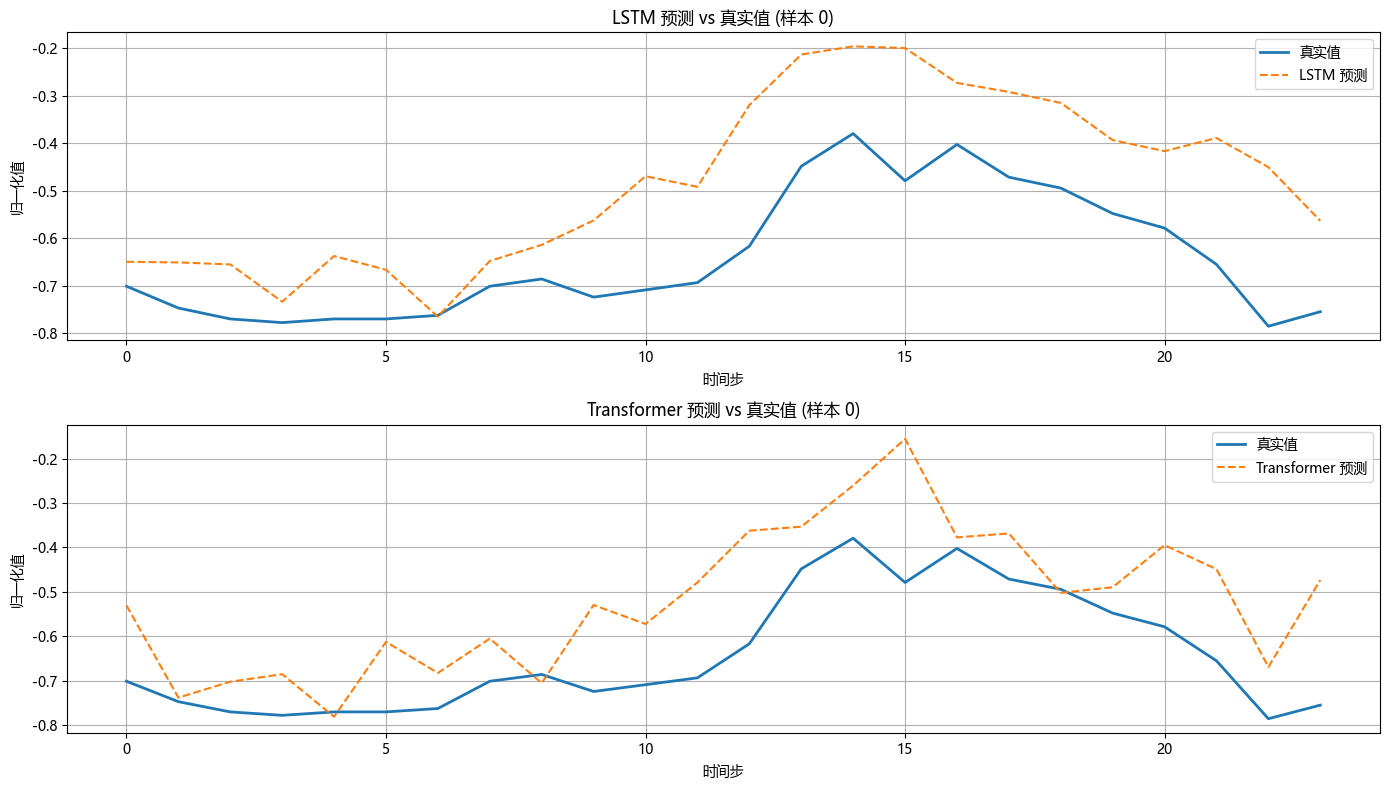

In [26]:
# 选择一个样本进行可视化
sample_idx = 0
n_steps = min(200, HORIZON)  # 显示前 200 个时间步

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# LSTM 预测
axes[0].plot(lstm_targets[sample_idx, :n_steps, target_idx], label='真实值', linewidth=2)
axes[0].plot(lstm_preds[sample_idx, :n_steps, target_idx], label='LSTM 预测', linestyle='--')
axes[0].set_title(f'LSTM 预测 vs 真实值 (样本 {sample_idx})')
axes[0].set_xlabel('时间步')
axes[0].set_ylabel('归一化值')
axes[0].legend()
axes[0].grid(True)

# Transformer 预测
axes[1].plot(transformer_targets[sample_idx, :n_steps, target_idx], label='真实值', linewidth=2)
axes[1].plot(transformer_preds[sample_idx, :n_steps, target_idx], label='Transformer 预测', linestyle='--')
axes[1].set_title(f'Transformer 预测 vs 真实值 (样本 {sample_idx})')
axes[1].set_xlabel('时间步')
axes[1].set_ylabel('归一化值')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. 保存结果

In [27]:
# 保存测试结果
results_dir = os.path.join(ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)

results = {
    'dataset': DATASET,
    'horizon': HORIZON,
    'lstm': lstm_metrics,
    'transformer': transformer_metrics
}

np.save(os.path.join(results_dir, f'{DATASET}_h{HORIZON}_results.npy'), results)
print(f'结果已保存至: {results_dir}/{DATASET}_h{HORIZON}_results.npy')

结果已保存至: c:\Users\LOKER\Desktop\Research-Training\results/ETTh1_h24_results.npy


In [28]:
# 打印最终结果
print('\n' + '=' * 60)
print('基础模型训练完成')
print('=' * 60)
print(f'数据集: {DATASET}')
print(f'预测步长: {HORIZON}')
print(f'LSTM 最佳验证损失: {lstm_history["best_val_loss"]:.6f}')
print(f'LSTM 最佳验证 R²: {lstm_history["best_val_r2"]:.4f}')
print(f'Transformer 最佳验证损失: {transformer_history["best_val_loss"]:.6f}')
print(f'Transformer 最佳验证 R²: {transformer_history["best_val_r2"]:.4f}')
print(f'\n模型已保存至: checkpoints/')
print('=' * 60)


基础模型训练完成
数据集: ETTh1
预测步长: 24
LSTM 最佳验证损失: 0.928657
LSTM 最佳验证 R²: 0.3304
Transformer 最佳验证损失: 0.679609
Transformer 最佳验证 R²: 0.4689

模型已保存至: checkpoints/
